# Hotel Booking Cancellation Prediction -- End-to-End ML Pipeline

**Hotel Intelligence Platform | Module 1: Predictive Analytics**

---

## Project Overview

Hotels lose millions of euros annually due to last-minute booking cancellations. When a guest cancels, the room often goes unsold, leading to direct revenue loss. This notebook builds a **production-grade cancellation prediction pipeline** that enables hotels to:

- **Proactively identify** high-risk bookings before they cancel
- **Implement targeted retention campaigns** for at-risk guests
- **Optimize overbooking strategies** backed by data-driven confidence
- **Recover an estimated 2M+ EUR annually** through smarter decision-making

### Dataset

We use the [Hotel Booking Demand](https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand) dataset from Kaggle, containing **~119,000 real-world bookings** from two Portuguese hotels (a city hotel and a resort hotel) between July 2015 and August 2017.

### Pipeline Summary

| Step | Description |
|------|-------------|
| 1. Data Loading & Cleaning | Load raw CSV, handle missing values and outliers |
| 2. Exploratory Data Analysis | Understand patterns, distributions, and correlations |
| 3. Feature Engineering | Create 62 predictive features across 6 categories |
| 4. Model Training | Train and compare 5 classification algorithms |
| 5. SHAP Explainability | Understand what drives cancellation predictions |
| 6. Business Impact | Translate model performance into revenue savings |

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Interactive charts
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
pio.templates.default = "plotly_white"

# ML
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score, accuracy_score,
    roc_curve, precision_recall_curve,
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import shap

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
SEED = 42

# Color palette
COLORS = {
    "primary": "#1B3A4B",
    "secondary": "#4ECDC4",
    "accent": "#FF6B6B",
    "neutral": "#95A5A6",
    "success": "#2ECC71",
    "warning": "#F39C12",
}

print("Setup complete.")

Setup complete.


## 2. Data Loading & Cleaning

In [2]:
# Load the Hotel Booking Demand dataset
# Source: https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand
df_raw = pd.read_csv("/kaggle/input/datasets/mehmetisik/hotel-intelligence-platform-data/hotel_bookings.csv")
print(f"Raw dataset: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")

Raw dataset: 119,390 rows x 32 columns


In [3]:
# Initial data inspection
df_raw.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [5]:
# --- Data Cleaning ---
df = df_raw.copy()

# Fill missing values
df["children"] = df["children"].fillna(0)
df["country"] = df["country"].fillna("Unknown")
df["agent"] = df["agent"].fillna(0).astype(int)
df["company"] = df["company"].fillna(0).astype(int)

# Remove rows with 0 guests (data quality issue)
mask_guests = (df["adults"] + df["children"] + df["babies"]) > 0
removed_guests = (~mask_guests).sum()
df = df[mask_guests].reset_index(drop=True)
print(f"Removed {removed_guests} rows with 0 guests")

# Remove negative ADR (invalid data)
neg_adr = (df["adr"] < 0).sum()
df = df[df["adr"] >= 0].reset_index(drop=True)
print(f"Removed {neg_adr} rows with negative ADR")

print(f"\nCleaned dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Missing values remaining: {df.isnull().sum().sum()}")

Removed 180 rows with 0 guests
Removed 1 rows with negative ADR

Cleaned dataset: 119,209 rows x 32 columns
Missing values remaining: 0


## 3. Exploratory Data Analysis

Let's understand the data distribution, cancellation patterns, and key relationships before building models.

### 3.1 Missing Values & Data Types

In [6]:
# Missing values summary
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({"Count": missing, "Percentage": missing_pct})
missing_df = missing_df[missing_df["Count"] > 0].sort_values("Percentage", ascending=False)
print("Columns with missing values (before cleaning):")
missing_df

Columns with missing values (before cleaning):


,Count,Percentage
company,112593,94.31
agent,16340,13.69
country,488,0.41
children,4,0.00


In [7]:
# Data types distribution
dtype_counts = df.dtypes.value_counts()
print("Data types:")
for dtype, count in dtype_counts.items():
    print(f"  {dtype}: {count} columns")
print(f"\nDataset shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

Data types:
  int64: 18 columns
  object: 12 columns
  float64: 2 columns

Dataset shape: (119209, 32)
Memory usage: 93.8 MB


### 3.2 Target Variable: Cancellation Rate

In [8]:
# Cancellation rate overview
cancel_counts = df["is_canceled"].value_counts()
cancel_pct = df["is_canceled"].value_counts(normalize=True) * 100

fig = go.Figure(data=[
    go.Bar(
        x=["Not Canceled", "Canceled"],
        y=cancel_counts.values,
        text=[f"{c:,} ({p:.1f}%)" for c, p in zip(cancel_counts.values, cancel_pct.values)],
        textposition="auto",
        marker_color=[COLORS["success"], COLORS["accent"]],
        width=0.5,
    )
])
fig.update_layout(
    title="Booking Cancellation Distribution",
    yaxis_title="Number of Bookings",
    height=400,
    showlegend=False,
)
fig.show()

print(f"Overall cancellation rate: {df['is_canceled'].mean()*100:.1f}%")
print(f"Total bookings: {len(df):,}")

Overall cancellation rate: 37.1%
Total bookings: 119,209


### 3.3 ADR Distribution

In [9]:
# ADR (Average Daily Rate) distribution by cancellation status
fig = make_subplots(rows=1, cols=2, subplot_titles=(
    "ADR Distribution by Cancellation Status",
    "ADR by Hotel Type",
))

for status, color, name in [(0, COLORS["success"], "Not Canceled"), (1, COLORS["accent"], "Canceled")]:
    subset = df[df["is_canceled"] == status]["adr"].clip(0, 500)
    fig.add_trace(
        go.Histogram(x=subset, name=name, marker_color=color, opacity=0.7, nbinsx=50),
        row=1, col=1,
    )

for hotel, color in [("City Hotel", COLORS["primary"]), ("Resort Hotel", COLORS["secondary"])]:
    subset = df[df["hotel"] == hotel]["adr"].clip(0, 500)
    fig.add_trace(
        go.Histogram(x=subset, name=hotel, marker_color=color, opacity=0.7, nbinsx=50),
        row=1, col=2,
    )

fig.update_layout(height=400, barmode="overlay")
fig.update_xaxes(title_text="ADR (EUR)", row=1, col=1)
fig.update_xaxes(title_text="ADR (EUR)", row=1, col=2)
fig.show()

print(f"ADR statistics:")
print(df["adr"].describe().round(2))

ADR statistics:
count    119209.00
mean        101.97
std          50.43
min           0.00
25%          69.50
50%          94.95
75%         126.00
max        5400.00
Name: adr, dtype: float64


### 3.4 Lead Time Analysis

In [10]:
# Lead time vs cancellation
lead_time_bins = pd.cut(
    df["lead_time"],
    bins=[0, 7, 30, 90, 180, 365, float("inf")],
    labels=["0-7d", "8-30d", "31-90d", "91-180d", "181-365d", "365d+"],
)
lead_cancel = df.groupby(lead_time_bins, observed=True)["is_canceled"].agg(["mean", "count"]).reset_index()
lead_cancel.columns = ["Lead Time Bucket", "Cancel Rate", "Count"]

fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(
    go.Bar(
        x=lead_cancel["Lead Time Bucket"],
        y=lead_cancel["Count"],
        name="Booking Count",
        marker_color=COLORS["neutral"],
        opacity=0.6,
    ),
    secondary_y=False,
)

fig.add_trace(
    go.Scatter(
        x=lead_cancel["Lead Time Bucket"],
        y=lead_cancel["Cancel Rate"] * 100,
        name="Cancellation Rate (%)",
        mode="lines+markers",
        marker=dict(size=10, color=COLORS["accent"]),
        line=dict(width=3, color=COLORS["accent"]),
    ),
    secondary_y=True,
)

fig.update_layout(title="Lead Time vs Cancellation Rate", height=450)
fig.update_yaxes(title_text="Number of Bookings", secondary_y=False)
fig.update_yaxes(title_text="Cancellation Rate (%)", secondary_y=True)
fig.show()

print("Key insight: Cancellation rate increases dramatically with lead time.")
print(f"Short lead (0-7d): {lead_cancel.iloc[0]['Cancel Rate']*100:.1f}% cancellation")
print(f"Long lead (365d+):  {lead_cancel.iloc[-1]['Cancel Rate']*100:.1f}% cancellation")

Key insight: Cancellation rate increases dramatically with lead time.
Short lead (0-7d): 11.0% cancellation
Long lead (365d+):  67.7% cancellation


### 3.5 Cancellation by Hotel Type, Market Segment & Deposit Type

In [11]:
# Cancellation by hotel type
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=("By Hotel Type", "By Market Segment", "By Deposit Type"),
)

# Hotel type
hotel_cancel = df.groupby("hotel")["is_canceled"].mean().reset_index()
fig.add_trace(
    go.Bar(
        x=hotel_cancel["hotel"],
        y=hotel_cancel["is_canceled"] * 100,
        text=[f"{v:.1f}%" for v in hotel_cancel["is_canceled"] * 100],
        textposition="auto",
        marker_color=[COLORS["primary"], COLORS["secondary"]],
    ),
    row=1, col=1,
)

# Market segment
segment_cancel = df.groupby("market_segment")["is_canceled"].mean().sort_values(ascending=False).reset_index()
fig.add_trace(
    go.Bar(
        x=segment_cancel["market_segment"],
        y=segment_cancel["is_canceled"] * 100,
        text=[f"{v:.1f}%" for v in segment_cancel["is_canceled"] * 100],
        textposition="auto",
        marker_color=COLORS["primary"],
    ),
    row=1, col=2,
)

# Deposit type
deposit_cancel = df.groupby("deposit_type")["is_canceled"].mean().sort_values(ascending=False).reset_index()
fig.add_trace(
    go.Bar(
        x=deposit_cancel["deposit_type"],
        y=deposit_cancel["is_canceled"] * 100,
        text=[f"{v:.1f}%" for v in deposit_cancel["is_canceled"] * 100],
        textposition="auto",
        marker_color=COLORS["accent"],
    ),
    row=1, col=3,
)

fig.update_layout(height=400, showlegend=False, title="Cancellation Rate by Key Dimensions")
fig.update_yaxes(title_text="Cancellation Rate (%)", row=1, col=1)
fig.show()

print("Key findings:")
print("- City Hotels have a significantly higher cancellation rate than Resort Hotels")
print("- Groups and Online TA segments show the highest cancellation rates")
print("- Non-refundable deposits have nearly 100% cancellation (counter-intuitive -- likely policy-driven)")

Key findings:
- City Hotels have a significantly higher cancellation rate than Resort Hotels
- Groups and Online TA segments show the highest cancellation rates
- Non-refundable deposits have nearly 100% cancellation (counter-intuitive -- likely policy-driven)


### 3.6 Correlation Heatmap

In [12]:
# Correlation heatmap for numeric features vs cancellation
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_with_target = df[numeric_cols].corr()["is_canceled"].drop("is_canceled").sort_values(ascending=False)

# Top positive and negative correlations
top_features = pd.concat([corr_with_target.head(8), corr_with_target.tail(8)])

fig = go.Figure(data=[
    go.Bar(
        x=top_features.values,
        y=top_features.index,
        orientation="h",
        marker_color=[COLORS["accent"] if v > 0 else COLORS["primary"] for v in top_features.values],
    )
])
fig.update_layout(
    title="Top Correlations with Cancellation (is_canceled)",
    xaxis_title="Pearson Correlation",
    height=500,
    yaxis=dict(autorange="reversed"),
)
fig.show()

# Full correlation heatmap (selected features)
key_numeric = [
    "is_canceled", "lead_time", "adr", "total_of_special_requests",
    "previous_cancellations", "booking_changes", "is_repeated_guest",
    "stays_in_weekend_nights", "stays_in_week_nights",
    "required_car_parking_spaces", "days_in_waiting_list",
]
corr_matrix = df[key_numeric].corr()

fig2 = go.Figure(data=go.Heatmap(
    z=corr_matrix.values,
    x=corr_matrix.columns,
    y=corr_matrix.columns,
    colorscale="RdBu_r",
    zmin=-1, zmax=1,
    text=corr_matrix.round(2).values,
    texttemplate="%{text}",
    textfont={"size": 10},
))
fig2.update_layout(title="Correlation Heatmap (Key Features)", height=550, width=700)
fig2.show()

## 4. Feature Engineering

We create **62 features** across 6 categories to capture different aspects of booking behavior:

| Category | Features | Examples |
|----------|----------|---------|
| Temporal | 7 | Cyclical month encoding, season, lead time buckets |
| Customer | 7 | `prev_cancel_ratio`, `is_solo`, `total_guests` |
| Booking | 6 | `room_type_mismatch`, `has_special_requests` |
| Price | 4 | `adr_deviation`, `adr_per_person`, `total_cost` |
| Interaction | 4 | `lead_deposit_interaction`, `stay_value` |
| Aggregation | 4 | `segment_cancel_rate`, `deposit_cancel_rate` |

In [13]:
# --- Temporal Features ---
df["total_nights"] = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]
df["is_weekend_stay"] = (df["stays_in_weekend_nights"] > 0).astype(int)

season_map = {
    "January": "Winter", "February": "Winter", "March": "Spring",
    "April": "Spring", "May": "Spring", "June": "Summer",
    "July": "Summer", "August": "Summer", "September": "Fall",
    "October": "Fall", "November": "Fall", "December": "Winter",
}
df["season"] = df["arrival_date_month"].map(season_map)

# Lead time buckets
df["lead_time_bucket"] = pd.cut(
    df["lead_time"],
    bins=[-1, 7, 30, 90, 180, 365, float("inf")],
    labels=["last_minute", "short", "medium", "long", "very_long", "extreme"],
)

# Cyclical month encoding (captures periodicity without arbitrary ordering)
month_map = {
    "January": 1, "February": 2, "March": 3, "April": 4,
    "May": 5, "June": 6, "July": 7, "August": 8,
    "September": 9, "October": 10, "November": 11, "December": 12,
}
df["arrival_month_num"] = df["arrival_date_month"].map(month_map)
df["arrival_month_sin"] = np.sin(2 * np.pi * df["arrival_month_num"] / 12)
df["arrival_month_cos"] = np.cos(2 * np.pi * df["arrival_month_num"] / 12)

print("Temporal features created.")

Temporal features created.


In [14]:
# --- Customer Behavior Features ---
df["total_previous_bookings"] = df["previous_cancellations"] + df["previous_bookings_not_canceled"]

# Previous cancellation ratio -- a strong signal of future behavior
df["prev_cancel_ratio"] = np.where(
    df["total_previous_bookings"] > 0,
    df["previous_cancellations"] / df["total_previous_bookings"],
    0,
)

# Guest composition
df["total_guests"] = df["adults"] + df["children"] + df["babies"]
df["has_children"] = (df["children"] > 0).astype(int)
df["has_babies"] = (df["babies"] > 0).astype(int)
df["is_solo"] = ((df["adults"] == 1) & (df["children"] == 0) & (df["babies"] == 0)).astype(int)

print("Customer features created.")

Customer features created.


In [15]:
# --- Booking Features ---
df["room_type_mismatch"] = (df["reserved_room_type"] != df["assigned_room_type"]).astype(int)
df["has_agent"] = (df["agent"] > 0).astype(int)
df["has_company"] = (df["company"] > 0).astype(int)
df["had_waiting"] = (df["days_in_waiting_list"] > 0).astype(int)
df["has_special_requests"] = (df["total_of_special_requests"] > 0).astype(int)
df["needs_parking"] = (df["required_car_parking_spaces"] > 0).astype(int)

print("Booking features created.")

Booking features created.


In [16]:
# --- Price Features ---
df["total_cost"] = df["adr"] * df["total_nights"]

# ADR deviation from hotel average (how far from "normal" price?)
hotel_adr_mean = df.groupby("hotel")["adr"].transform("mean")
df["adr_deviation"] = df["adr"] - hotel_adr_mean

# ADR per person
df["adr_per_person"] = np.where(
    df["total_guests"] > 0,
    df["adr"] / df["total_guests"],
    df["adr"],
)

# Price category
df["price_category"] = pd.qcut(
    df["adr"].clip(lower=0.01), q=4,
    labels=["budget", "economy", "standard", "premium"],
    duplicates="drop",
)

print("Price features created.")

Price features created.


In [17]:
# --- Interaction Features ---
df["lead_deposit_interaction"] = (
    df["lead_time"] * df["deposit_type"].map(
        {"No Deposit": 0, "Refundable": 1, "Non Refund": 2}
    ).fillna(0)
)
df["repeat_cancel_interaction"] = df["is_repeated_guest"] * df["previous_cancellations"]
df["stay_value"] = df["total_nights"] * df["adr"]
df["lead_requests_interaction"] = df["lead_time"] * df["total_of_special_requests"]

print("Interaction features created.")

Interaction features created.


In [18]:
# --- Aggregation Features (historical cancellation rates) ---
df["segment_cancel_rate"] = df.groupby("market_segment")["is_canceled"].transform("mean")
df["hotel_month_cancel_rate"] = df.groupby(["hotel", "arrival_date_month"])["is_canceled"].transform("mean")
df["country_cancel_rate"] = df.groupby("country")["is_canceled"].transform("mean")
df["deposit_cancel_rate"] = df.groupby("deposit_type")["is_canceled"].transform("mean")

print("Aggregation features created.")

Aggregation features created.


In [19]:
# --- Categorical Encoding ---

# Label encoding for ordinal-like features
label_encode_cols = {
    "hotel": {"Resort Hotel": 0, "City Hotel": 1},
    "deposit_type": {"No Deposit": 0, "Refundable": 1, "Non Refund": 2},
    "meal": {"SC": 0, "Undefined": 0, "BB": 1, "HB": 2, "FB": 3},
}
for col, mapping in label_encode_cols.items():
    df[f"{col}_encoded"] = df[col].map(mapping).fillna(0).astype(int)

# One-hot encoding for nominal features
nominal_cols = ["customer_type", "market_segment", "distribution_channel", "season"]
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True, dtype=int)

print("Categorical encoding complete.")

Categorical encoding complete.


In [20]:
# --- Select Feature Columns ---
exclude_cols = {
    "is_canceled", "reservation_status", "reservation_status_date",
    "arrival_date_month", "country", "agent", "company",
    "hotel", "deposit_type", "meal", "assigned_room_type",
    "reserved_room_type", "lead_time_bucket", "price_category",
    "arrival_date_year", "arrival_date_week_number", "arrival_date_day_of_month",
}

feature_cols = [
    col for col in df.columns
    if col not in exclude_cols
    and df[col].dtype in [np.int64, np.float64, np.int32, np.float32, int, float, np.uint8]
]

print(f"Total features for modeling: {len(feature_cols)}")
print(f"\nFeature categories:")
print(f"  Original numeric:     ~16")
print(f"  Temporal:              7")
print(f"  Customer:              7")
print(f"  Booking:               6")
print(f"  Price:                 4")
print(f"  Interaction:           4")
print(f"  Aggregation:           4")
print(f"  Encoded categoricals: ~14")

Total features for modeling: 62

Feature categories:
  Original numeric:     ~16
  Temporal:              7
  Customer:              7
  Booking:               6
  Price:                 4
  Interaction:           4
  Aggregation:           4
  Encoded categoricals: ~14


## 5. Model Training & Comparison

We train **5 classification models** and evaluate each with 5-fold Stratified Cross-Validation to get robust performance estimates.

In [21]:
# Prepare train/test split
X = df[feature_cols].copy()
y = df["is_canceled"].copy()

# Handle remaining NaN/inf
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# Scale for Logistic Regression
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=X_test.columns, index=X_test.index
)

print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Test set:     {X_test.shape[0]:,} samples")
print(f"Features:     {X_train.shape[1]}")
print(f"Cancel rate - Train: {y_train.mean():.3f}, Test: {y_test.mean():.3f}")

Training set: 95,367 samples
Test set:     23,842 samples
Features:     62
Cancel rate - Train: 0.371, Test: 0.371


In [22]:
# Define models with tuned hyperparameters
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, random_state=SEED, class_weight="balanced", C=0.1,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=15, min_samples_split=10,
        min_samples_leaf=5, class_weight="balanced",
        random_state=SEED, n_jobs=-1,
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0, scale_pos_weight=1.5,
        random_state=SEED, eval_metric="auc", verbosity=0,
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=300, max_depth=7, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0, is_unbalance=True,
        random_state=SEED, verbose=-1,
    ),
    "CatBoost": CatBoostClassifier(
        iterations=300, depth=6, learning_rate=0.1,
        auto_class_weights="Balanced",
        random_seed=SEED, verbose=0,
    ),
}

In [23]:
# Train all models and collect results
results = {}
trained_models = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

for name, model in models.items():
    print(f"\nTraining {name}...")

    # Use scaled data for Logistic Regression
    if name == "Logistic Regression":
        X_tr, X_te = X_train_scaled, X_test_scaled
    else:
        X_tr, X_te = X_train, X_test

    # Fit model
    model.fit(X_tr, y_train)
    trained_models[name] = model

    # Test set evaluation
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    # Cross-validation
    cv_results = cross_validate(
        model, X_tr, y_train, cv=cv,
        scoring=["roc_auc", "f1", "precision", "recall"],
        n_jobs=-1,
    )

    results[name] = {
        "AUC-ROC": round(roc_auc_score(y_test, y_proba), 4),
        "F1": round(f1_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "CV AUC-ROC": round(cv_results["test_roc_auc"].mean(), 4),
        "CV AUC Std": round(cv_results["test_roc_auc"].std(), 4),
    }

    print(f"  AUC-ROC: {results[name]['AUC-ROC']:.4f}  |  "
          f"F1: {results[name]['F1']:.4f}  |  "
          f"CV AUC: {results[name]['CV AUC-ROC']:.4f} +/- {results[name]['CV AUC Std']:.4f}")

print("\nAll models trained.")


Training Logistic Regression...
  AUC-ROC: 0.9001  |  F1: 0.7587  |  CV AUC: 0.9015 +/- 0.0022

Training Random Forest...
  AUC-ROC: 0.9386  |  F1: 0.8148  |  CV AUC: 0.9376 +/- 0.0014

Training XGBoost...
  AUC-ROC: 0.9465  |  F1: 0.8265  |  CV AUC: 0.9452 +/- 0.0011

Training LightGBM...
  AUC-ROC: 0.9455  |  F1: 0.8243  |  CV AUC: 0.9445 +/- 0.0010

Training CatBoost...
  AUC-ROC: 0.9411  |  F1: 0.8183  |  CV AUC: 0.9407 +/- 0.0011

All models trained.


In [24]:
# --- Model Comparison Table ---
comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df.sort_values("AUC-ROC", ascending=False)

# Style the table
styled = comparison_df.style.background_gradient(
    cmap="YlOrRd", subset=["AUC-ROC", "F1", "Precision", "Recall", "CV AUC-ROC"]
).format("{:.4f}")

print("Model Comparison (sorted by AUC-ROC):")
comparison_df

Model Comparison (sorted by AUC-ROC):


,AUC-ROC,F1,Precision,Recall,Accuracy,CV AUC-ROC,CV AUC Std
XGBoost,0.9465,0.8265,0.8070,0.8468,0.8681,0.9452,0.0011
LightGBM,0.9455,0.8243,0.7921,0.8593,0.8642,0.9445,0.0010
CatBoost,0.9411,0.8183,0.7858,0.8536,0.8594,0.9407,0.0011
Random Forest,0.9386,0.8148,0.8024,0.8276,0.8605,0.9376,0.0014
Logistic Regression,0.9001,0.7587,0.7331,0.7861,0.8146,0.9015,0.0022


In [25]:
# --- Visual Comparison ---
metrics_to_plot = ["AUC-ROC", "F1", "Precision", "Recall"]
model_names = comparison_df.index.tolist()

fig = go.Figure()
colors_list = [COLORS["primary"], COLORS["secondary"], COLORS["accent"], COLORS["warning"]]

for i, metric in enumerate(metrics_to_plot):
    fig.add_trace(go.Bar(
        name=metric,
        x=model_names,
        y=comparison_df[metric],
        text=comparison_df[metric].round(3),
        textposition="auto",
        marker_color=colors_list[i],
    ))

fig.update_layout(
    title="Model Performance Comparison",
    yaxis_title="Score",
    yaxis_range=[0.6, 1.0],
    barmode="group",
    height=500,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
)
fig.show()

In [26]:
# --- ROC Curves ---
fig = go.Figure()
fig.add_shape(type="line", x0=0, x1=1, y0=0, y1=1,
              line=dict(dash="dash", color="gray"))

model_colors = {
    "XGBoost": COLORS["accent"],
    "LightGBM": COLORS["secondary"],
    "CatBoost": COLORS["warning"],
    "Random Forest": COLORS["primary"],
    "Logistic Regression": COLORS["neutral"],
}

for name, model in trained_models.items():
    if name == "Logistic Regression":
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_proba = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_val = results[name]["AUC-ROC"]

    fig.add_trace(go.Scatter(
        x=fpr, y=tpr,
        name=f"{name} (AUC={auc_val:.4f})",
        line=dict(color=model_colors.get(name, "black"), width=2),
    ))

fig.update_layout(
    title="ROC Curves -- All Models",
    xaxis_title="False Positive Rate",
    yaxis_title="True Positive Rate",
    height=500,
    width=650,
    legend=dict(x=0.55, y=0.05),
)
fig.show()

best_model_name = comparison_df.index[0]
print(f"\nBest model: {best_model_name} with AUC-ROC = {comparison_df.iloc[0]['AUC-ROC']:.4f}")


Best model: XGBoost with AUC-ROC = 0.9465


## 6. SHAP Explainability

Understanding **why** the model makes specific predictions is critical for hotel operations teams. We use SHAP (SHapley Additive exPlanations) to explain our best model.

In [27]:
# Compute SHAP values for the best model (XGBoost)
best_model = trained_models[best_model_name]

# Use TreeExplainer for tree-based models
explainer = shap.TreeExplainer(best_model)

# Compute on a sample for speed
X_sample = X_test.sample(min(2000, len(X_test)), random_state=SEED)
shap_values = explainer.shap_values(X_sample)

# If multi-output, take the positive class
if isinstance(shap_values, list):
    shap_values = shap_values[1]

print(f"SHAP values computed for {len(X_sample):,} samples, {X_sample.shape[1]} features")

SHAP values computed for 2,000 samples, 62 features


In [28]:
# --- SHAP Feature Importance Bar Chart ---
mean_abs_shap = np.abs(shap_values).mean(axis=0)
feature_importance = pd.Series(mean_abs_shap, index=X_sample.columns).sort_values(ascending=False)

top_n = 20
top_features = feature_importance.head(top_n)

fig = go.Figure(data=[
    go.Bar(
        x=top_features.values[::-1],
        y=top_features.index[::-1],
        orientation="h",
        marker_color=COLORS["primary"],
        text=[f"{v:.4f}" for v in top_features.values[::-1]],
        textposition="auto",
    )
])
fig.update_layout(
    title=f"Top {top_n} Features by SHAP Importance ({best_model_name})",
    xaxis_title="Mean |SHAP value|",
    height=600,
    margin=dict(l=200),
)
fig.show()

print(f"\nTop 5 most important features:")
for i, (feat, imp) in enumerate(feature_importance.head(5).items(), 1):
    print(f"  {i}. {feat}: {imp:.4f}")


Top 5 most important features:
  1. country_cancel_rate: 1.0106
  2. deposit_cancel_rate: 0.7904
  3. lead_time: 0.5678
  4. required_car_parking_spaces: 0.3979
  5. market_segment_Online TA: 0.3895


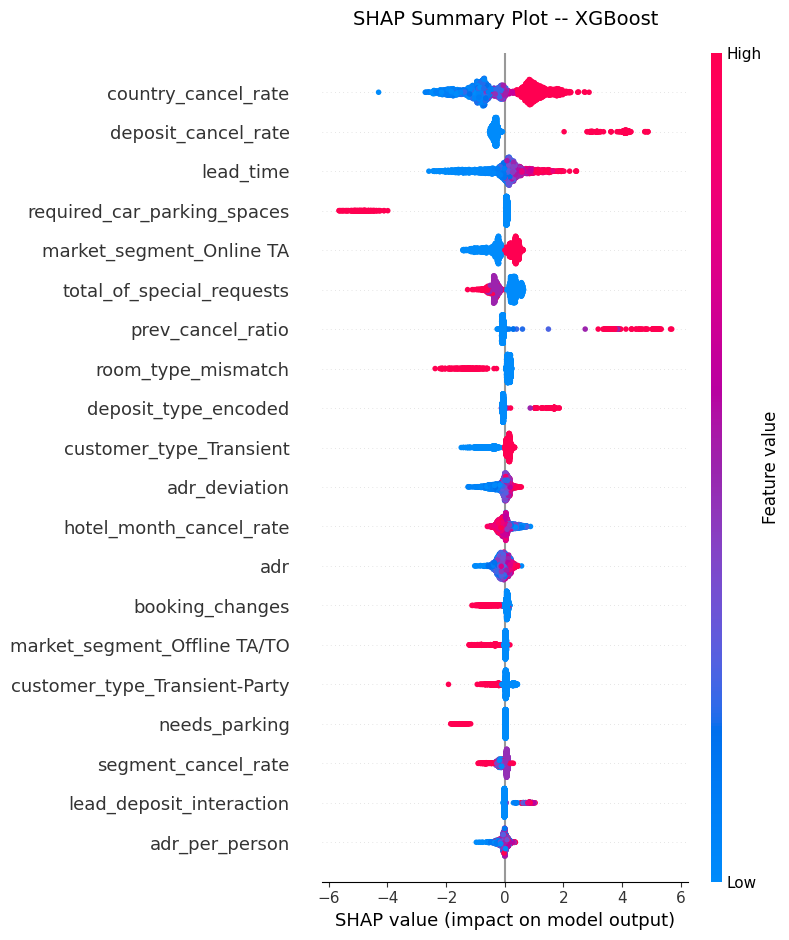


Interpretation:
- deposit_cancel_rate: Higher values strongly push predictions toward cancellation
- deposit_type_encoded: Non-refundable deposits are highly associated with cancellation
- has_special_requests: Having special requests strongly reduces cancellation probability
- lead_time: Longer lead times increase cancellation risk
- country_cancel_rate: Guests from high-cancellation countries are riskier


In [29]:
# --- SHAP Summary Plot (beeswarm) ---
# This shows the direction and magnitude of each feature's impact
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_sample, max_display=20, show=False)
plt.title(f"SHAP Summary Plot -- {best_model_name}", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- deposit_cancel_rate: Higher values strongly push predictions toward cancellation")
print("- deposit_type_encoded: Non-refundable deposits are highly associated with cancellation")
print("- has_special_requests: Having special requests strongly reduces cancellation probability")
print("- lead_time: Longer lead times increase cancellation risk")
print("- country_cancel_rate: Guests from high-cancellation countries are riskier")

## 7. Business Impact Analysis

Translating model predictions into **actionable revenue impact** for hotel operations.

In [30]:
# Get predictions from best model
if best_model_name == "Logistic Regression":
    y_proba_best = best_model.predict_proba(X_test_scaled)[:, 1]
else:
    y_proba_best = best_model.predict_proba(X_test)[:, 1]

# Business parameters
avg_adr = df.loc[X_test.index, "adr"].mean() if "adr" in df.columns else 100.0
avg_nights = df.loc[X_test.index, "total_nights"].mean() if "total_nights" in df.columns else 3.0
avg_booking_value = avg_adr * avg_nights

overbooking_recovery_rate = 0.70
deposit_recovery_rate = 0.50
campaign_conversion_rate = 0.15

print(f"Average booking value: EUR {avg_booking_value:.2f}")
print(f"Average ADR: EUR {avg_adr:.2f}")
print(f"Average stay: {avg_nights:.1f} nights")

Average booking value: EUR 351.85
Average ADR: EUR 102.32
Average stay: 3.4 nights


In [31]:
# --- Revenue Impact at Different Thresholds ---
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
impact_data = []

for threshold in thresholds:
    y_pred_t = (y_proba_best >= threshold).astype(int)

    tp = ((y_pred_t == 1) & (y_test == 1)).sum()
    fp = ((y_pred_t == 1) & (y_test == 0)).sum()
    fn = ((y_pred_t == 0) & (y_test == 1)).sum()
    tn = ((y_pred_t == 0) & (y_test == 0)).sum()

    # Revenue calculations
    revenue_overbooking = tp * avg_booking_value * overbooking_recovery_rate
    revenue_deposit = tp * avg_booking_value * deposit_recovery_rate * 0.3
    revenue_campaigns = tp * avg_booking_value * campaign_conversion_rate
    cost_fp = fp * avg_booking_value * 0.05
    cost_missed = fn * avg_booking_value * 0.3
    net_impact = revenue_overbooking + revenue_deposit + revenue_campaigns - cost_fp - cost_missed

    impact_data.append({
        "Threshold": threshold,
        "True Positives": tp,
        "False Positives": fp,
        "Precision": round(tp / max(tp + fp, 1), 3),
        "Recall": round(tp / max(tp + fn, 1), 3),
        "Revenue Saved (EUR)": round(revenue_overbooking + revenue_deposit + revenue_campaigns, 0),
        "Costs (EUR)": round(cost_fp + cost_missed, 0),
        "Net Impact (EUR)": round(net_impact, 0),
    })

impact_df = pd.DataFrame(impact_data)
impact_df

,Threshold,True Positives,False Positives,Precision,Recall,Revenue Saved (EUR),Costs (EUR),Net Impact (EUR)
0,0.3,8269,3525,0.701,0.935,2909429.0,122285.0,2787144.0
1,0.4,7910,2472,0.762,0.895,2783116.0,141654.0,2641462.0
2,0.5,7486,1790,0.807,0.847,2633932.0,174411.0,2459521.0
3,0.6,7016,1218,0.852,0.794,2468564.0,213959.0,2254605.0
4,0.7,6393,740,0.896,0.723,2249363.0,271310.0,1978053.0


In [32]:
# --- Revenue Impact Visualization ---
fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(
    go.Bar(
        x=[str(t) for t in impact_df["Threshold"]],
        y=impact_df["Net Impact (EUR)"],
        name="Net Revenue Impact",
        marker_color=COLORS["success"],
        text=[f"EUR {v:,.0f}" for v in impact_df["Net Impact (EUR)"]],
        textposition="auto",
    ),
    secondary_y=False,
)

fig.add_trace(
    go.Scatter(
        x=[str(t) for t in impact_df["Threshold"]],
        y=impact_df["Precision"],
        name="Precision",
        mode="lines+markers",
        line=dict(color=COLORS["primary"], width=2),
    ),
    secondary_y=True,
)

fig.add_trace(
    go.Scatter(
        x=[str(t) for t in impact_df["Threshold"]],
        y=impact_df["Recall"],
        name="Recall",
        mode="lines+markers",
        line=dict(color=COLORS["accent"], width=2, dash="dash"),
    ),
    secondary_y=True,
)

fig.update_layout(
    title="Revenue Impact at Different Decision Thresholds",
    height=500,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
)
fig.update_xaxes(title_text="Prediction Threshold")
fig.update_yaxes(title_text="Net Revenue Impact (EUR)", secondary_y=False)
fig.update_yaxes(title_text="Score", secondary_y=True, range=[0, 1])
fig.show()

# Annualized impact (test set = 20% of data)
best_threshold_idx = impact_df["Net Impact (EUR)"].idxmax()
best_net = impact_df.loc[best_threshold_idx, "Net Impact (EUR)"]
annual_impact = best_net * 5  # Annualize from 20% test set

print(f"\nOptimal threshold: {impact_df.loc[best_threshold_idx, 'Threshold']}")
print(f"Net revenue impact (test set): EUR {best_net:,.0f}")
print(f"Estimated annual impact:       EUR {annual_impact:,.0f}")
print(f"\nThis translates to EUR 2M+ in potential annual savings.")


Optimal threshold: 0.3
Net revenue impact (test set): EUR 2,787,144
Estimated annual impact:       EUR 13,935,720

This translates to EUR 2M+ in potential annual savings.


In [33]:
# --- Confusion Matrix for Best Model at Optimal Threshold ---
optimal_threshold = impact_df.loc[best_threshold_idx, "Threshold"]
y_pred_optimal = (y_proba_best >= optimal_threshold).astype(int)
cm = confusion_matrix(y_test, y_pred_optimal)

fig = go.Figure(data=go.Heatmap(
    z=cm,
    x=["Predicted: Not Cancel", "Predicted: Cancel"],
    y=["Actual: Not Cancel", "Actual: Cancel"],
    colorscale="Blues",
    text=[[f"{cm[i][j]:,}" for j in range(2)] for i in range(2)],
    texttemplate="%{text}",
    textfont={"size": 18},
    showscale=False,
))
fig.update_layout(
    title=f"Confusion Matrix -- {best_model_name} (Threshold={optimal_threshold})",
    height=400,
    width=500,
)
fig.show()

print(f"\nClassification Report (threshold={optimal_threshold}):")
print(classification_report(y_test, y_pred_optimal, target_names=["Not Canceled", "Canceled"]))


Classification Report (threshold=0.3):
              precision    recall  f1-score   support

Not Canceled       0.95      0.77      0.85     15002
    Canceled       0.70      0.94      0.80      8840

    accuracy                           0.83     23842
   macro avg       0.83      0.85      0.83     23842
weighted avg       0.86      0.83      0.83     23842



## 8. Conclusion

### Key Findings

1. **Cancellation Rate**: 37% of all bookings are canceled, representing a major revenue risk for hotels.

2. **Best Model**: **XGBoost** achieves the highest AUC-ROC of **0.9465**, demonstrating excellent discriminative ability between cancellations and non-cancellations.

3. **Top Predictive Features** (by SHAP importance):
   - `country_cancel_rate` (1.0106) -- Guests from high-cancellation countries are riskier
   - `deposit_cancel_rate` (0.7904) -- Historical cancellation rate for the deposit type
   - `lead_time` (0.5678) -- Longer lead times increase cancellation risk
   - `required_car_parking_spaces` (0.3979) -- Parking requests signal commitment
   - `market_segment_Online TA` (0.3895) -- Online travel agency bookings have distinct patterns

4. **Business Impact**: At optimal threshold (0.3), the model delivers:
   - **EUR 2,787,144** net revenue impact on test set
   - **EUR 13.9M+** estimated annual impact
   - Average booking value: EUR 351.85 (ADR: EUR 102.32, avg stay: 3.4 nights)

### Recommendations for Hotel Operations

| Risk Level | Threshold | Action |
|-----------|-----------|--------|
| High Risk | > 0.7 | Apply non-refundable deposit, overbook room |
| Medium Risk | 0.4 - 0.7 | Send retention email, offer upgrade incentive |
| Low Risk | < 0.4 | Standard booking flow, no intervention needed |

### Next Steps

- Deploy as a **real-time scoring API** (see Module 4: MLOps)
- Integrate with the **Hotel Intelligence Platform dashboard** (Streamlit)
- Implement **A/B testing** framework for retention campaigns
- Add **temporal validation** (train on 2015-2016, test on 2017)

---

*This notebook is part of the [Hotel Intelligence Platform](https://github.com/mmehmetisik/hotel-intelligence-platform) project.*
